Cargamos las librerías necesarias 

In [1]:
import os                                               # Nos permite interactuar con el sistema operativo.
import neat                                             # La usamos para la evolución de redes neuronales.
from sklearn.model_selection import train_test_split    # Para dividir el conjunto de datos en entrenamiento y prueba.
import importlib
import visualize                                        # Para visualizar los resultados de la evolución.
importlib.reload(visualize) 


<module 'visualize' from 'c:\\Users\\munlo\\Desktop\\python\\RNAClases\\visualize.py'>

In [2]:
from sklearn.datasets import load_wine                  # Para cargar el conjunto de datos de vinos.
from sklearn.preprocessing import MinMaxScaler          # Para escalar las características del conjunto de datos.
import random

Cargamos la base de datos, escalamos y dividimos en datos de prueba y entrenamiento.

In [3]:
wine = load_wine()
X = wine.data
y = wine.target

scaler = MinMaxScaler(feature_range=(0, 1))
X = scaler.fit_transform(X)

seed = 42
random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

Definimos la función que nos permite evaluar cada genoma de una población. Le llamamos eval_genomes, y los argumentos que recibe son una lista de genomas y la configuración establecida de NEAT.

In [4]:

def eval_genomes(genomes, config):
    for genome_id, genome in genomes:                               # Iteramos sobre cada genoma
        correct_predictions = 0                                     #contaremos cada acierto del genoma.
        net = neat.nn.FeedForwardNetwork.create(genome, config)     # Creamos una red neuronal a partir del genoma
        for xi, target in zip(X_train, y_train):                    # Para cada muestra de entrada y su etiqueta correspondiente en el conjunto de datos de vinos
            output = net.activate(xi)                               # Obtenemos la salida de la red neuronal para la muestra de entrada
            prediction = output.index(max(output))                  # Obtenemos la clase predicha por la red neuronal (la clase con la salida más alta)
            if prediction == target:
                correct_predictions += 1
        genome.fitness = correct_predictions / len(X_train)         # Calculamos la precisión del genoma como su fitness (número de predicciones correctas dividido por el número total de muestras)


La función run es la función principal que ejecuta el algoritmo NEAT. Carga la configuración del algoritmo desde un archivo de configuración, crea una población de genomas, agrega reportes para mostrar información sobre el progreso del algoritmo, y ejecuta el algoritmo durante un máximo de 200 generaciones utilizando la función eval_genomes para evaluar los genomas en cada generación. Después de ejecutar el algoritmo, imprime el genoma ganador, muestra la salida de la red neuronal creada a partir del genoma ganador para cada muestra de entrada en el conjunto de datos de vinos, y visualiza la estructura de la red neuronal ganadora y las estadísticas del progreso del algoritmo NEAT a lo largo de las generaciones.

In [5]:

def run(config_file):
    '''Cargamos la configuración del algoritmo NEAT desde el archivo de configuración'''
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_file)

    '''Creamos la población de genomas a partir de la configuración cargada''' 
    p = neat.Population(config)

    '''# Agregamos reportes para mostrar información sobre el progreso del algoritmo'''
    p.add_reporter(neat.StdOutReporter(True))
    stats = neat.StatisticsReporter()
    p.add_reporter(stats)
    p.add_reporter(neat.Checkpointer(5))


    '''Ejecutamos el algoritmo NEAT durante un máximo de 200 generaciones, 
       evaluando los genomas en cada generación utilizando la función eval_genomes'''

    winner = p.run(eval_genomes, 200)

    '''# Imprimimos el genoma ganador (el genoma con la mejor precisión en la clasificación de los vinos)'''
    print(f'\nBest genome:\n{winner!s}')

    '''Mostramos la salida de la red neuronal creada a partir del genoma ganador para cada muestra de entrada en el
       conjunto de datos de vinos, comparando la salida con la etiqueta esperada (la clase del vino) y mostrando la
       precisión de las predicciones. También visualizamos la estructura de la red neuronalganadora y las
       estadísticas del progreso del algoritmo NEAT a lo largo de las generaciones.'''
    print('\nOutput:') 

    '''Creamos una red neuronal a partir del genoma ganador para evaluar el rendimiento en el conjunto de prueba'''
    winner_net = neat.nn.FeedForwardNetwork.create(winner, config)
    correct = 0
    estimados = []
    for xi, xo in zip(X_test, y_test):          # Para cada muestra de entrada (registros) y su etiqueta correspondiente en el conjunto de prueba
        output = winner_net.activate(xi)
        prediction = output.index(max(output))  # Obtenemos la clase predicha por la red neuronal (la clase con la salida más alta)
        estimados.append(prediction)
       # print(f"input {xi!r}, expected output {xo!r}, got {output!r}")
        if prediction == xo:
            correct += 1  # Calculamos la precisión del genoma ganador en el conjunto de prueba (1.0 si la predicción es correcta, 0.0 si es incorrecta)
   # Imprimimos la precisión del genoma ganador en el conjunto de prueba
    accuracy = correct / len(X_test)
    print(f'Precisión: {accuracy * 100:.2f}%')

    input_names = {-(i+1): name for i, name in enumerate(wine.feature_names)}
    output_names = {0: 'Vino 1', 1: 'Vino 2', 2: 'Vino 3'}

    node_names = {**input_names, **output_names}
    #visualize.draw_net(config, winner, True, node_names=node_names)
    visualize.draw_net(config, winner, True, node_names=node_names, prune_unused=True)
    visualize.plot_stats(stats, ylog=False, view=True)
    visualize.plot_species(stats, view=True)
    visualize.plot_error_hist(estimados, y_test)
    visualize.plot_confusion_matrix(y_test, estimados, classes=wine.target_names, view=True)
   
    

    #p = neat.Checkpointer.restore_checkpoint('neat-checkpoint-4')
    #p.run(eval_genomes, 10)

Función principal para ejecutar el programa


 ****** Running generation 0 ****** 

Population's average fitness: 0.32793 stdev: 0.10332
Best fitness: 0.58451 - size: (3, 39) - species 1 - id 18
Average adjusted fitness: 0.279
Mean genetic distance 1.269, standard deviation 0.240
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    0   150      0.585    0.279     0
Total extinctions: 0
Generation time: 0.392 sec

 ****** Running generation 1 ****** 

Population's average fitness: 0.40094 stdev: 0.11495
Best fitness: 0.70423 - size: (4, 41) - species 1 - id 278
Average adjusted fitness: 0.373
Mean genetic distance 1.427, standard deviation 0.234
Population of 150 members in 1 species (after reproduction):
   ID   age  size   fitness   adj fit  stag
  ====  ===  ====  =========  =======  ====
     1    1   150      0.704    0.373     0
Total extinctions: 0
Generation time: 0.507 sec (0.450 average)

 ****** Running generation 2

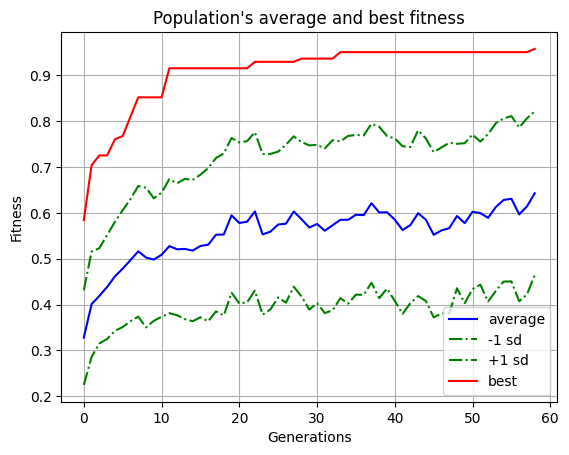

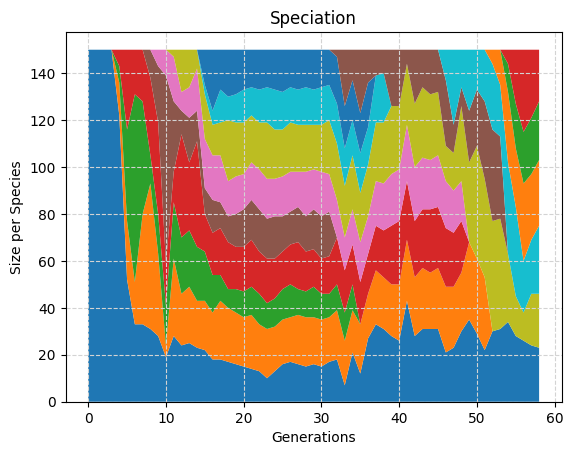

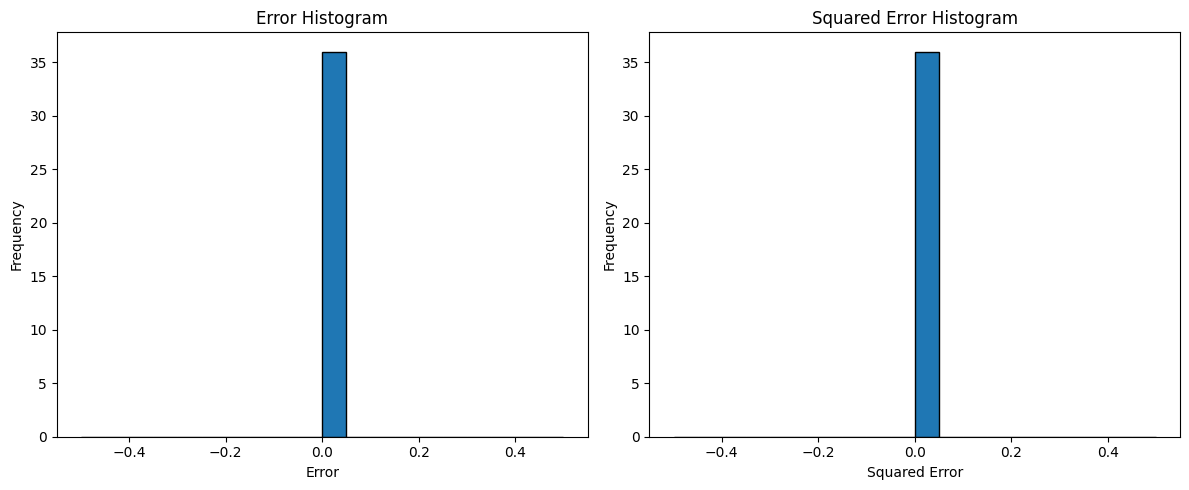

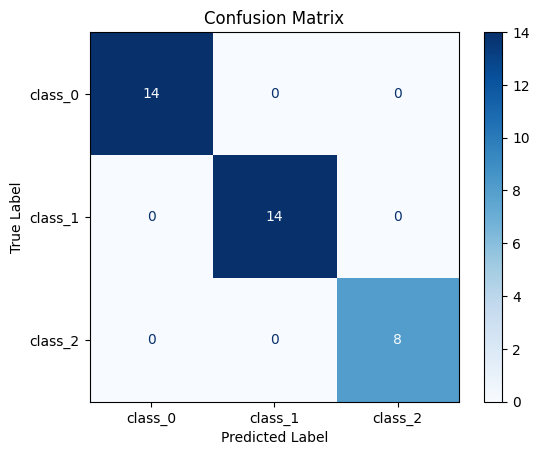

In [6]:
if __name__ == '__main__':
    '''Determinamos la ruta al archivo de configuración. Esta manipulación de rutas está aquí para que el script
       se ejecute correctamente independientemente del directorio de trabajo actual.'''
    #local_dir = os.path.dirname(__file__)                   # Obtenemos el directorio donde se encuentra el script actual
    config_path = 'config-wine'    # Construimos la ruta completa al archivo de configuración 'config-wine' que se encuentra en el mismo directorio que el script
    run(config_path)                                        # Ejecutamos la función principal 'run' pasando la ruta al archivo de configuración como argumento